In [12]:
import torch
from torch import nn
!pip install torchviz
from torchviz import make_dot
import matplotlib.pyplot as plt

## 간단한 인공신경망

Linear(in_features=1, out_features=1, bias=True)
Parameter containing:
tensor([[-0.2872]], requires_grad=True)
Parameter containing:
tensor([0.1555], requires_grad=True)
tensor([-0.1317], grad_fn=<ViewBackward0>)
tensor([-0.1317], grad_fn=<AddBackward0>)


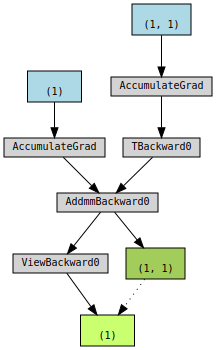

In [ ]:
x = torch.tensor([1.]) # 인공 신경망의 입력은 float 이여야함.
model = nn.Linear(1,1) # 입력 node 한 개, 출력 node 한 개인 layer 만듦
print(model)

print(model.weight) # 만들면서 initialize 자동적으로 함
print(model.bias)   # 미분해서 학습할 변수들이므로 requires_grad=True가 default.

y = model(x)
print(y)

y2 = x @ model.weight + model.bias # 식으로 나타내 본다면 이런 꼴
print(y2)

make_dot(y)

Parameter containing:
tensor([[-0.8270],
        [-0.5671],
        [ 0.4973]], requires_grad=True)
Parameter containing:
tensor([ 0.7092, -0.5852,  0.5263], requires_grad=True)
Parameter containing:
tensor([[-0.1814, -0.0266, -0.2629]], requires_grad=True)
Parameter containing:
tensor([-0.3010], requires_grad=True)
tensor([-0.1177, -1.1524,  1.0237], grad_fn=<ViewBackward0>)
tensor([-0.5181], grad_fn=<ViewBackward0>)
tensor([-0.5181], grad_fn=<AddBackward0>)


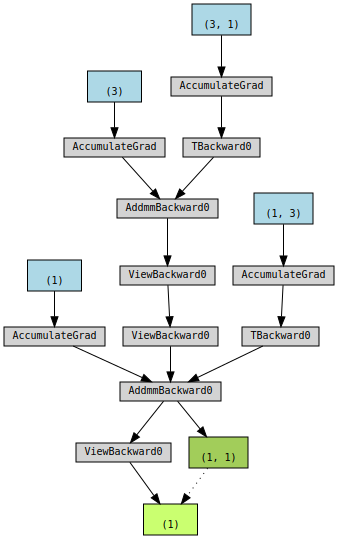

In [ ]:
fc1 = nn.Linear(1,3)
fc2 = nn.Linear(3,1)

print(fc1.weight)
print(fc1.bias)
print(fc2.weight)
print(fc2.bias)
# 균등분포(Uniform) 기반의 Kaiming(He) 초기화를 사용한다.
# weight: Uniform(-1/√n, 1/√n)에서 랜덤 샘플링 (n = in_features)
# bias: 동일하게 Uniform(-1/√n, 1/√n)에서 샘플링 (n = in_features)

x = torch.tensor([1.])
x = fc1(x)
print(x)
y = fc2(x)
print(y)

x = torch.tensor([1.])
y2 = (x@fc1.weight.T + fc1.bias) @ fc2.weight.T + fc2.bias 
# pytorch는 nn.Linear(n,m) 일때 입력 벡터(n,), weight(m,n), bias(m,), 출력 벡터(m,) 으로 주어진다.
# 따라서 행렬곱을 시키려면 weight 행렬을 전치시켜야함.
# 1차원 tensor의 곱은 자동적으로 (1,n) 처럼 1을 임시로 붙여 (1,n) 행렬처럼 취급해 곱셈을 하고 결과에서 1을 다시 제거함.
print(y2)

make_dot(y)

tensor([-0.1618,  0.1719])
tensor([-0.3960,  0.3942,  0.5307], grad_fn=<ViewBackward0>)


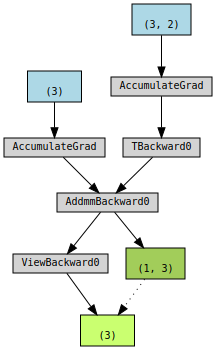

In [ ]:
model = nn.Linear(2,3)
x = torch.randn(2)
print(x)
print(model(x))
# nn.Linear은 데이터의 shape의 마지막 차원이 '채'로(1D data) 들어오길 기대한다.
# 입력 노드 하나가 곧 하나의 채널(피쳐) 값을 의미

make_dot(model(x))

tensor([[ 2.0152, -0.0983],
        [-0.7604, -1.1926],
        [ 0.9438,  1.6245],
        [ 0.5818,  0.1173],
        [-0.8071, -0.7508]])
tensor([[-0.7998,  0.6304,  0.2517],
        [-0.6581, -0.0666,  0.3637],
        [ 0.1126,  1.2214,  0.5845],
        [-0.4145,  0.5835,  0.4149],
        [-0.4717,  0.1062,  0.4278]], grad_fn=<AddmmBackward0>)
torch.Size([4, 5, 3])
torch.Size([2, 3, 6, 4, 5, 3])


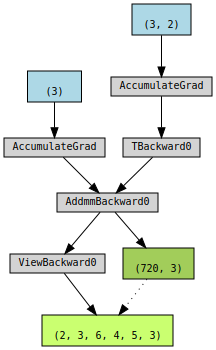

In [ ]:
model = nn.Linear(2,3)
# 따라서, 데이터 여러 개를 통과시키고 싶다면 개x채 의 형태로 줘야함.
x = torch.randn(5,2) # 개x채 => 두 개의 채널 값(키, 몸무게)을 가지는 데이터(사람) 5개

print(x)
print(model(x))

x = torch.randn(4,5,2) # 개x개x채 형태로 들어가는 형태. 5명의 사람으로 이뤄진 4개의 조의 형태를 생각하면 된다.
# LLM에서 5개의 단어를 가진 4개의 문장 이런 형태로 분절시켜서 입력이 가능하다.
print(model(x).shape)

x = torch.randn(2,3,6,4,5,2) # 2개의 학교, 3개의 학년, 6개의 반, 4개의 조, 5명 씩 이뤄진 데이터를 생각하면 된다.
print(model(x).shape)

make_dot(model(x))

# 그렇다면 왜 weight 행렬이 (m,n) 으로 주어질까? => 데이터와 마찬가지로 개x채 형태로 만들기 위함.
# 예를 들어, nn.Linear(2,3) 이면 두 채널 값을 사용하는 세 '개'의 필터를 통과하는 것이라 3x2 가 된다.
# 데이터 개채는 두 채널 값을 가지는 열 개의 데이터 (10x2)
# 웨이트 개채는 두 채널 값을 이용하는 세 개의 필터 (3x2)

tensor([-0.6094,  0.3965,  0.9082], grad_fn=<ViewBackward0>)
tensor([0.1077], grad_fn=<ViewBackward0>)
tensor([0.1077], grad_fn=<ViewBackward0>)


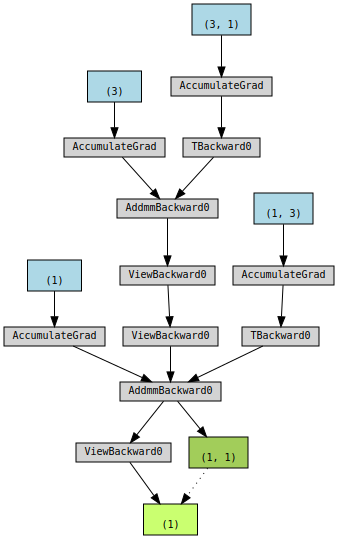

In [ ]:
fc1 = nn.Linear(1,3)
fc2 = nn.Linear(3,1)

x = torch.tensor([1.])
x = fc1(x)
print(x)
x = fc2(x)
print(x)

model = nn.Sequential(fc1,fc2)
x = torch.Tensor([1.])
print(model(x))

make_dot(model(x)) # Sequential 이 그림에 표현되진 않음

In [ ]:
model = nn.Sequential(nn.Linear(2,5), # (in_채널, out_채널) 이니까 연결된느 부분이 같아야 함.
                      nn.Linear(5,10),
                      nn.Linear(10,3))

x = torch.randn(5,2)
print(x)
print(model(x))

tensor([[ 1.3563,  0.6906],
        [ 0.2302, -0.4677],
        [-1.2165, -1.5798],
        [-0.4596,  0.7632],
        [ 0.8055, -0.1359]])
tensor([[ 0.1844, -0.0658,  0.1699],
        [-0.0253, -0.0091,  0.0012],
        [-0.2616,  0.0604, -0.1818],
        [ 0.0169,  0.0082,  0.0719],
        [ 0.0590, -0.0357,  0.0641]], grad_fn=<AddmmBackward0>)


tensor([[0.4597, 0.5979, 0.5345],
        [0.4584, 0.5969, 0.5357],
        [0.4603, 0.5994, 0.5363],
        [0.4595, 0.5982, 0.5359],
        [0.4611, 0.5997, 0.5341]], grad_fn=<SigmoidBackward0>)


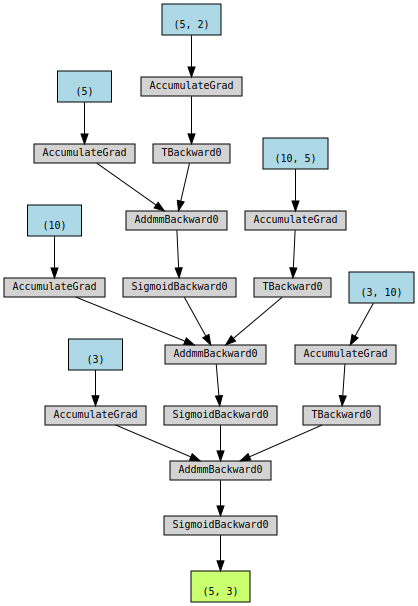

In [18]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(2,5)
        self.fc2 = nn.Linear(5,10)
        self.fc3 = nn.Linear(10,3)
        self.act = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)
        x = self.act(x)
        return x

model = MyModel()
x = torch.randn(5,2)
y = model(x) # model_forward(x) (nn.Module 의 __call__에서 foward를 통과시킴)
print(y)

make_dot(y)

tensor([[0.6609, 0.5949, 0.4350],
        [0.6662, 0.5918, 0.4387],
        [0.6638, 0.5975, 0.4355],
        [0.6656, 0.5947, 0.4374],
        [0.6702, 0.5860, 0.4425]], grad_fn=<SigmoidBackward0>)


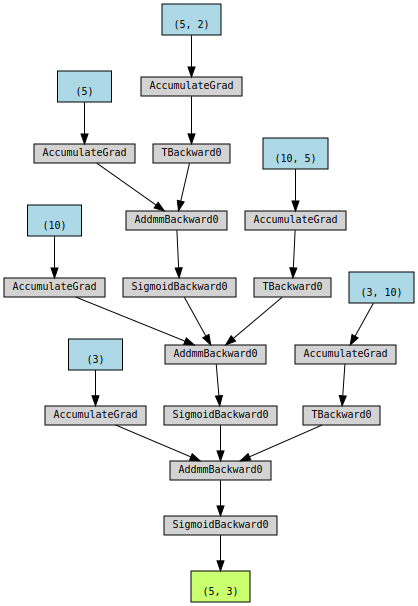

In [20]:
class MyModel2(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Sequential(nn.Linear(2,5),
                                    nn.Sigmoid(),
                                    nn.Linear(5,10),
                                    nn.Sigmoid(),
                                    nn.Linear(10,3),
                                    nn.Sigmoid())
        
    def forward(self, x):
        x = self.linear(x)
        return x

model2 = MyModel2()
x = torch.randn(5,2)
y = model2(x)
print(y)

make_dot(y)

In [ ]:
print(model2)
print(model2.linear[0].weight)
print(model2.linear[-2].bias) # [-1] 은 Sigmoid() 기 때문에 bias를 가져오려고 하면 오류가 뜸.

MyModel2(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=5, out_features=10, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=10, out_features=3, bias=True)
    (5): Sigmoid()
  )
)
Parameter containing:
tensor([[ 0.5815,  0.4972],
        [ 0.1750, -0.6940],
        [ 0.5659,  0.3907],
        [ 0.2689, -0.6391],
        [-0.3499,  0.5771]], requires_grad=True)
Parameter containing:
tensor([0.2047, 0.2915, 0.0546], requires_grad=True)


In [22]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.1196, -0.1741],
         [-0.4083, -0.6232],
         [-0.1993, -0.4896],
         [-0.3775,  0.0836],
         [ 0.1950,  0.2447]], requires_grad=True),
 Parameter containing:
 tensor([ 0.4922, -0.6573, -0.4100, -0.3635, -0.5463], requires_grad=True),
 Parameter containing:
 tensor([[ 0.2244, -0.4266, -0.2883,  0.2856, -0.1385],
         [-0.3975,  0.1412,  0.0298, -0.2900,  0.1366],
         [ 0.1636, -0.2407,  0.0922, -0.2559,  0.2278],
         [-0.3828, -0.2133, -0.0036, -0.0448, -0.0259],
         [-0.1202,  0.3516, -0.1716, -0.4467, -0.1563],
         [-0.1956, -0.1197, -0.0221, -0.1948,  0.0073],
         [-0.2515, -0.0921,  0.1656, -0.1811,  0.3511],
         [ 0.1143,  0.2188, -0.4094, -0.3252,  0.1308],
         [ 0.1573, -0.3544,  0.4238, -0.3164, -0.3296],
         [ 0.4409,  0.4390,  0.0142,  0.4199, -0.2198]], requires_grad=True),
 Parameter containing:
 tensor([ 0.3475, -0.1916,  0.2856,  0.2449, -0.4453,  0.1651,  0.0683,  0.3409,
  

In [23]:
# 파라미터 수 구하기
num = sum([p.numel() for p in model.parameters() if p.requires_grad])
print(num)

108


## 선형회귀 실습

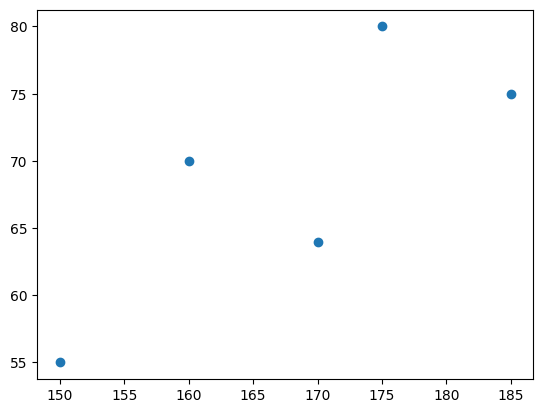

In [2]:
x = torch.tensor([150, 160, 170, 175, 185.]) # 키
y = torch.tensor([55, 70, 64, 80, 75.]) # 몸무게
N = len(x)
plt.plot(x,y,'o')

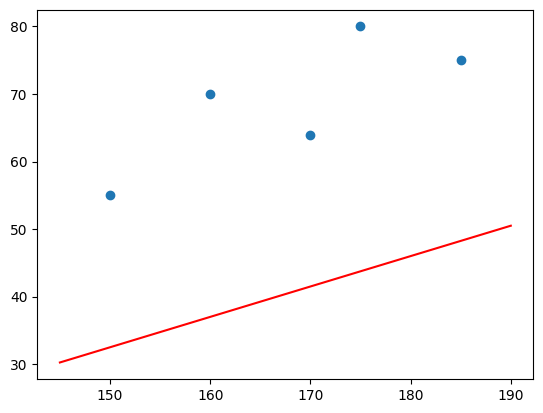

In [3]:
# 초기값 설정
a = 0.45
b = -35
x_plot = torch.linspace(145,190,100)
y_plot = a*x_plot + b

plt.plot(x,y,'o')
plt.plot(x_plot,y_plot,'r')

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


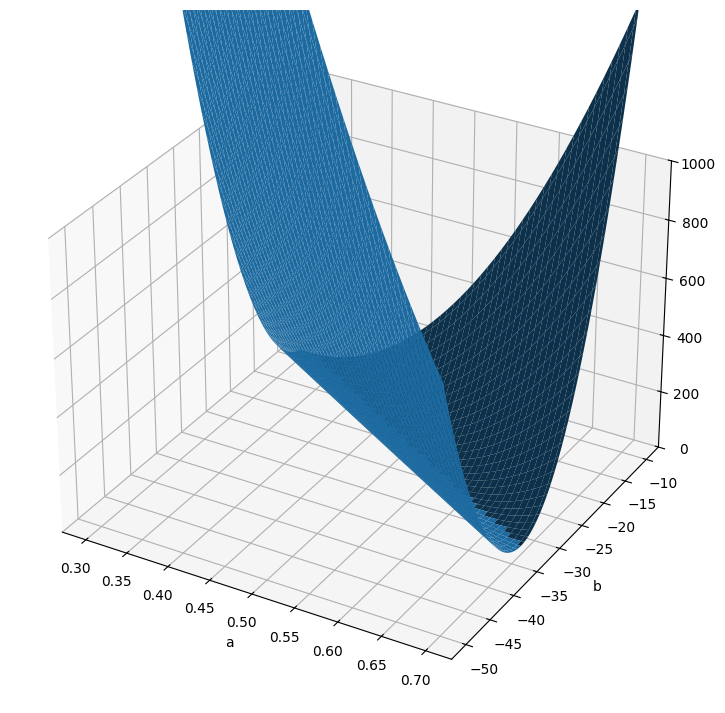

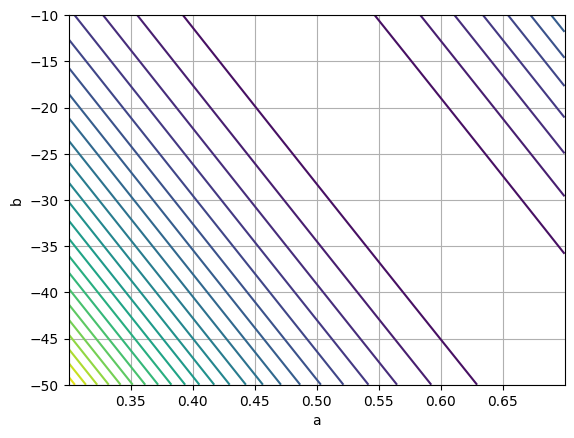

In [5]:
# a,b 를 바꿔가면서 Loss 값을 일일히 구해서 가장 작아지게 하는 a,b를 선정

a = 0.5 + torch.linspace(-0.2,0.2,100)
b = -30 + torch.linspace(-20,20,100)

L = torch.zeros(len(b),len(a))
for i in range(len(b)):
    for j in range(len(a)):
        for n in range(N):
            L[i,j] = L[i,j] + (y[n] - (a[j]*x[n]+b[i]))**2

L = L/N # MSE

plt.figure(figsize=[10,9])
ax = plt.axes(projection='3d')
A, B = torch.meshgrid(a,b)
ax.plot_surface(A,B,L)
ax.set_xlabel('a'); ax.set_ylabel('b')
ax.set_zlim([0,1000])

plt.figure()
plt.contour(a,b,L,30)
plt.xlabel('a'); plt.ylabel('b'); plt.grid()

In [6]:
L

tensor([[4717.8999, 4625.1914, 4533.4097,  ...,   37.8939,   35.0339,
           33.1000],
        [4662.7900, 4570.6304, 4479.3970,  ...,   35.9905,   33.6789,
           32.2935],
        [4608.0068, 4516.3955, 4425.7109,  ...,   34.4135,   32.6504,
           31.8136],
        ...,
        [ 892.4518,  852.9494,  814.3732,  ..., 1373.4280, 1423.7732,
         1475.0457],
        [ 869.0127,  830.0588,  792.0311,  ..., 1403.1949, 1454.0889,
         1505.9099],
        [ 845.8998,  807.4945,  770.0153,  ..., 1433.2881, 1484.7303,
         1537.1000]])

In [7]:
print(torch.min(L))
a_opt = A[L==torch.min(L)]
b_opt = B[L==torch.min(L)]
print(f"optimal a = {a_opt}")
print(f"optimal b = {b_opt}")

tensor(29.0315)
optimal a = tensor([0.5424])
optimal b = tensor([-23.7374])


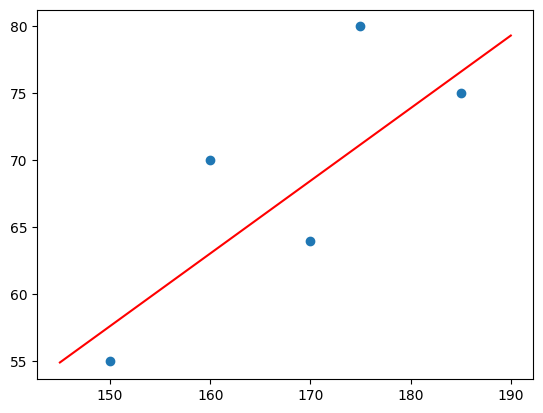

In [9]:
x_plot = torch.linspace(145,190,100)
y_plot = a_opt * x_plot + b_opt
plt.plot(x,y,'o')
plt.plot(x_plot,y_plot,'r')

In [16]:
!pip install nbformat
import plotly.io as pio
pio.renderers.default = "vscode"
fig = go.Figure(data=[go.Surface(x=b, y=a, z=L, colorscale="viridis", opacity=0.5)])
fig.update_traces(contours_z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True))
fig.update_layout(title='Loss', width=700, height=600,
                  scene = dict( xaxis_title='b', yaxis_title='a', zaxis_title='Loss', zaxis=dict(nticks=20, range=[0,1000]) ))

Epoch: 1, train loss: 826.2250
Weight: 0.4785, Bias: -34.9998


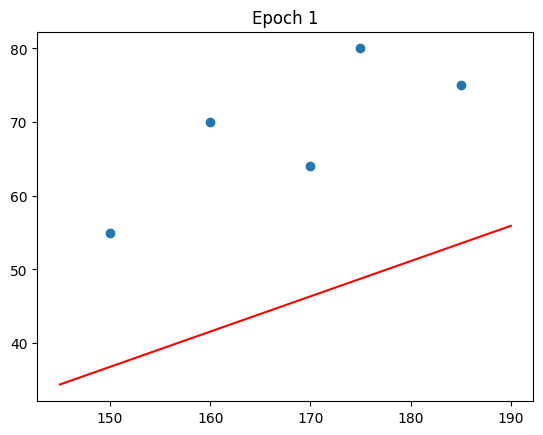

----------------------------------------
Epoch: 2, train loss: 578.0414
Weight: 0.5022, Bias: -34.9997


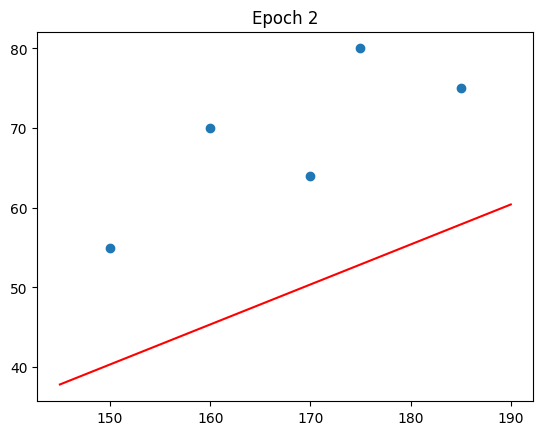

----------------------------------------
Epoch: 3, train loss: 407.1602
Weight: 0.5218, Bias: -34.9996


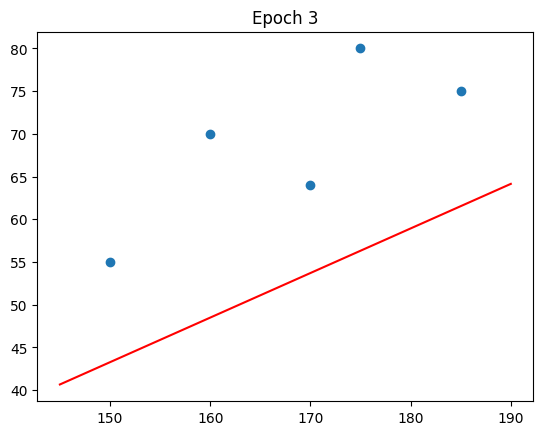

----------------------------------------
Epoch: 4, train loss: 289.5042
Weight: 0.5381, Bias: -34.9995


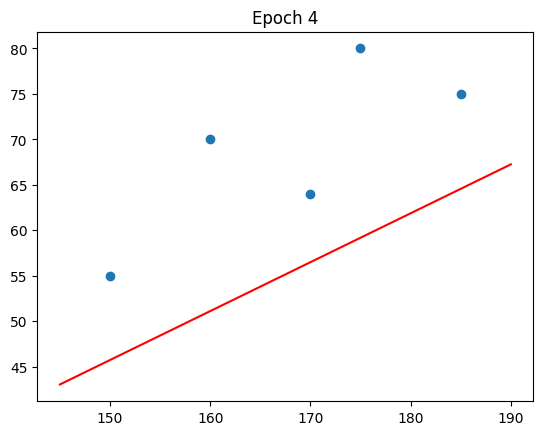

----------------------------------------
Epoch: 5, train loss: 208.4954
Weight: 0.5517, Bias: -34.9994


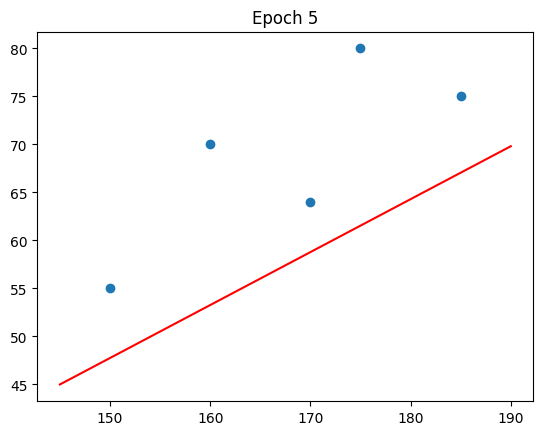

----------------------------------------
Epoch: 6, train loss: 152.7187
Weight: 0.5629, Bias: -34.9993


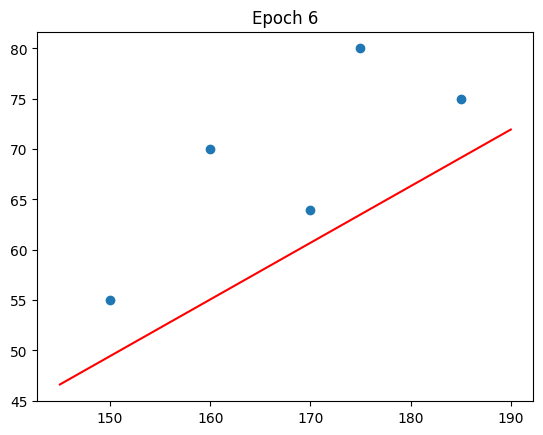

----------------------------------------
Epoch: 7, train loss: 114.3153
Weight: 0.5722, Bias: -34.9993


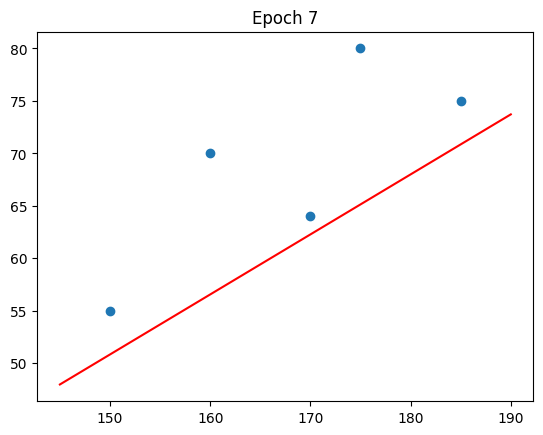

----------------------------------------
Epoch: 8, train loss: 87.8735
Weight: 0.5799, Bias: -34.9992


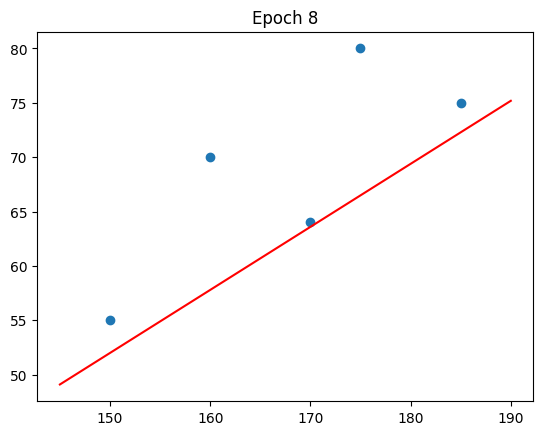

----------------------------------------
Epoch: 9, train loss: 69.6676
Weight: 0.5863, Bias: -34.9992


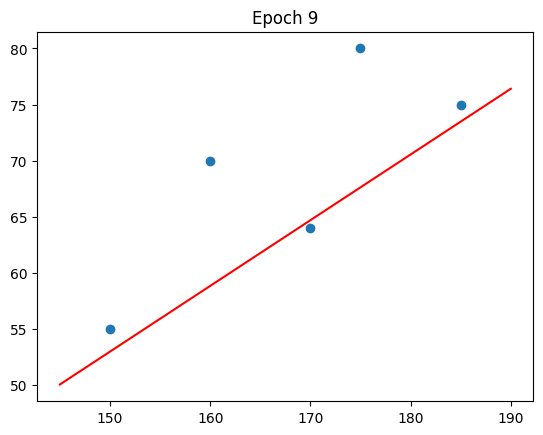

----------------------------------------
Epoch: 10, train loss: 57.1324
Weight: 0.5917, Bias: -34.9992


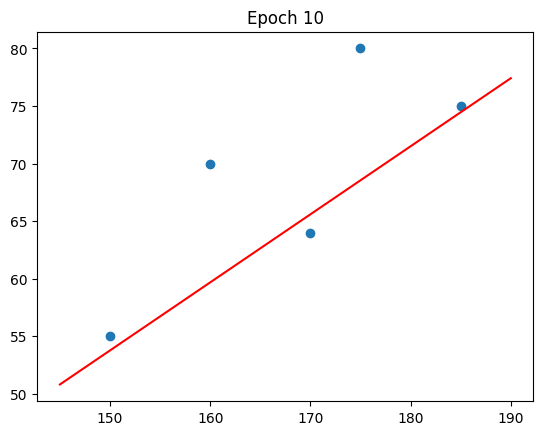

----------------------------------------
Epoch: 11, train loss: 48.5017
Weight: 0.5961, Bias: -34.9991


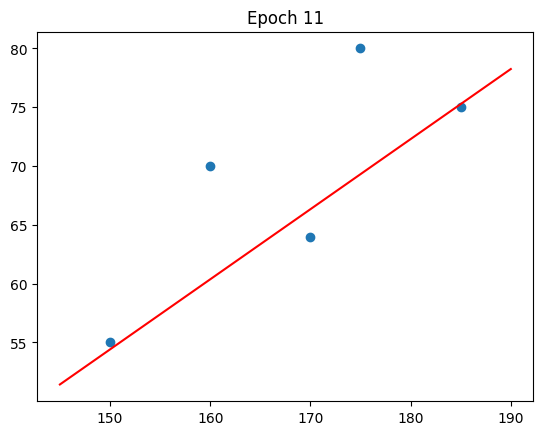

----------------------------------------
Epoch: 12, train loss: 42.5591
Weight: 0.5997, Bias: -34.9991


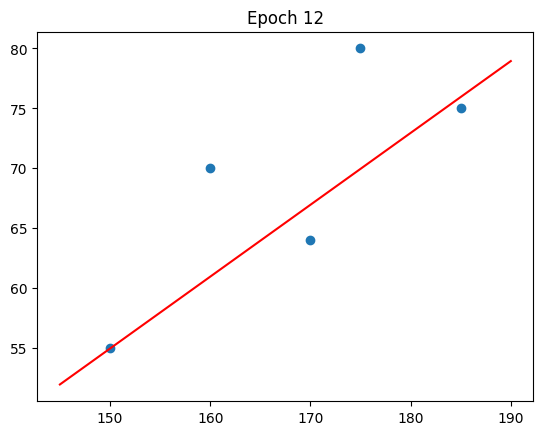

----------------------------------------
Epoch: 13, train loss: 38.4676
Weight: 0.6028, Bias: -34.9991


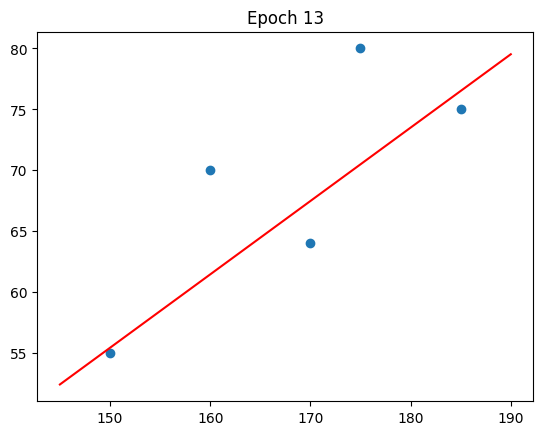

----------------------------------------
Epoch: 14, train loss: 35.6504
Weight: 0.6053, Bias: -34.9991


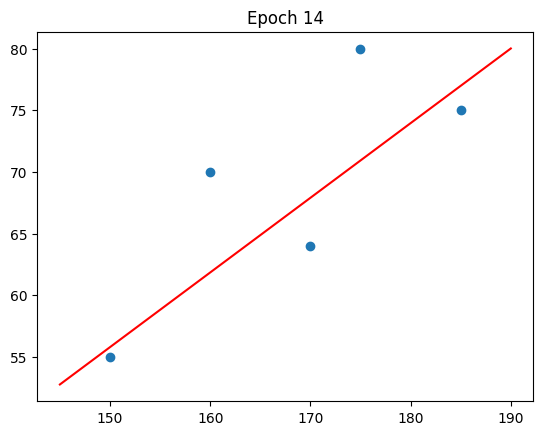

----------------------------------------
Epoch: 15, train loss: 33.7107
Weight: 0.6074, Bias: -34.9991


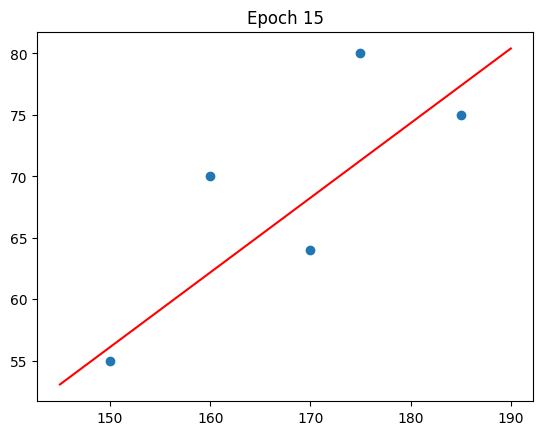

----------------------------------------
Epoch: 16, train loss: 32.3752
Weight: 0.6091, Bias: -34.9991


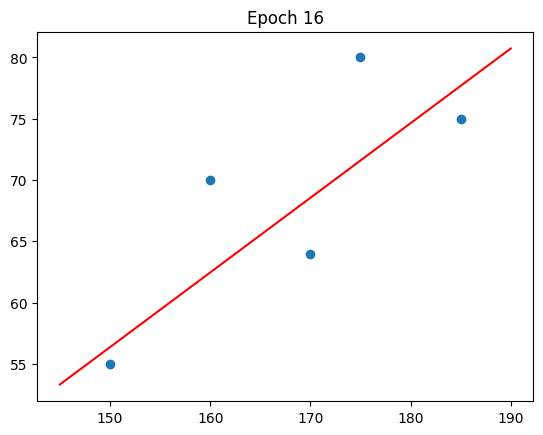

----------------------------------------
Epoch: 17, train loss: 31.4557
Weight: 0.6106, Bias: -34.9990


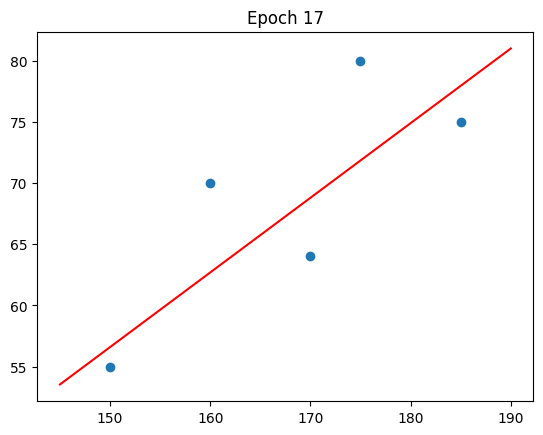

----------------------------------------
Epoch: 18, train loss: 30.8226
Weight: 0.6118, Bias: -34.9990


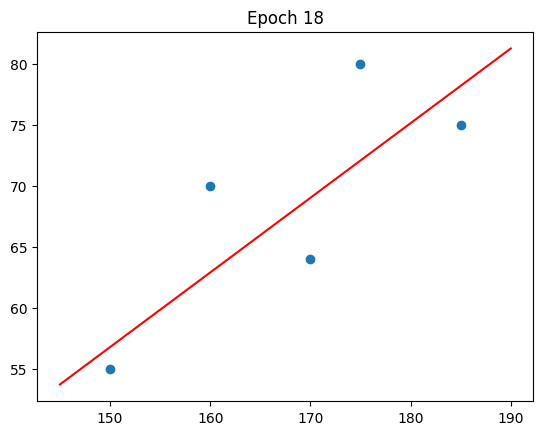

----------------------------------------
Epoch: 19, train loss: 30.3866
Weight: 0.6127, Bias: -34.9990


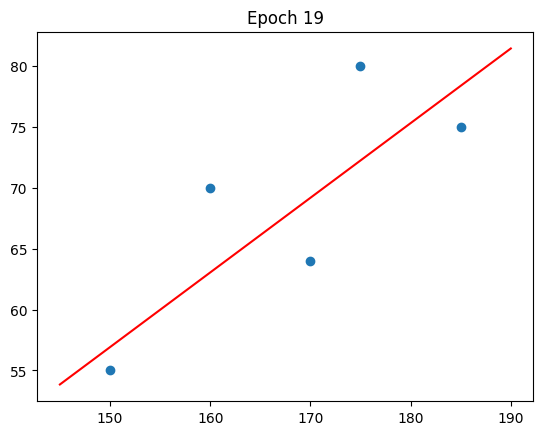

----------------------------------------
Epoch: 20, train loss: 30.0865
Weight: 0.6136, Bias: -34.9990


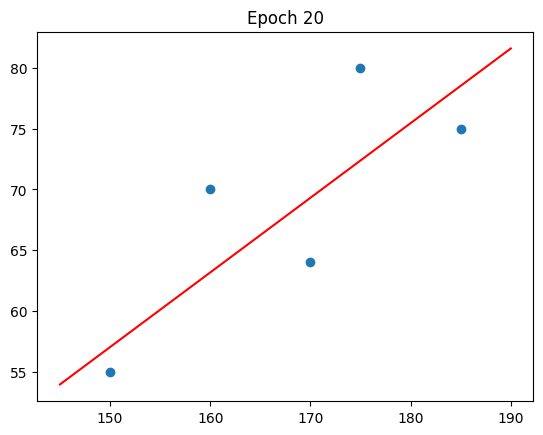

----------------------------------------


In [ ]:
# 모델 파라미터 초기화
a = torch.tensor([0.45], requires_grad=True)
b = torch.tensor([-35.], requires_grad=True)

# 하이퍼파라미터 설정
LR = 3e-6
EPOCH = 20

loss_history = []

for ep in range(EPOCH):
    # inference
    y_hat = a*x + b
    # loss
    loss = 0
    for n in range(N):
        loss += (y[n] - y_hat[n])**2
    loss = loss/N # MSE
    # loss = ((y - y_hat)**2).mean() <-- 간단한 버전.
    #update
    loss.backward() # backpropagation
    with torch.no_grad():
        a -= LR * a.grad # weight update
        b -= LR * b.grad # bias update
    a.grad = torch.tensor([0.]) # gradient 초기화
    b.grad = torch.tensor([0.]) # gradient 초기화
    # print loss
    loss_history += [loss.item()]
    print(f"Epoch: {ep+1}, train loss: {loss.item():.4f}")
    # print weight and bias
    print(f"Weight: {a.item():.4f}, Bias: {b.item():.4f}")
    # plot graph
    x_plot = torch.linspace(145,190,100)
    y_plot = a.detach() * x_plot + b.detach()
    plt.figure()
    plt.plot(x,y,'o')
    plt.plot(x_plot,y_plot,'r')
    plt.title(f"Epoch {ep+1}")
    plt.show()

    print("-"*40)

In [ ]:
# .grad 초기화 필요한 이유 실험
z = torch.tensor([1.], requires_grad=True)
for _ in range(2):
    loss = z**2
    loss.backward()
    print(z.grad)
    # z.grad = torch.tensor([0.])
    # print(z.grad)

# .backward()를 호출할 때마다 .grad에 새로 계산된 gradient를 덮어쓰는 게 아니라 누적 시킴

tensor([2.])
tensor([4.])


Text(0.5, 1.0, 'Training Loss')

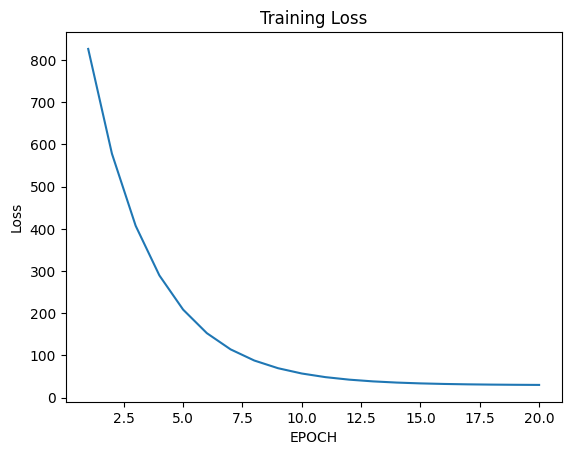

In [21]:
# plot loss_history
plt.plot(range(1, EPOCH+1), loss_history)
plt.xlabel("EPOCH")
plt.ylabel("Loss")
plt.title("Training Loss")

Epoch: 1, train loss: 900.5650
Weight: 0.4780, Bias: -34.9998


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning:

Using a target size (torch.Size([5])) that is different to the input size (torch.Size([5, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.



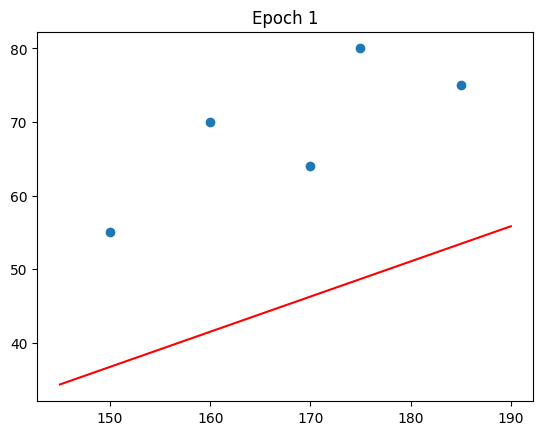

----------------------------------------
Epoch: 2, train loss: 660.9294
Weight: 0.5013, Bias: -34.9997


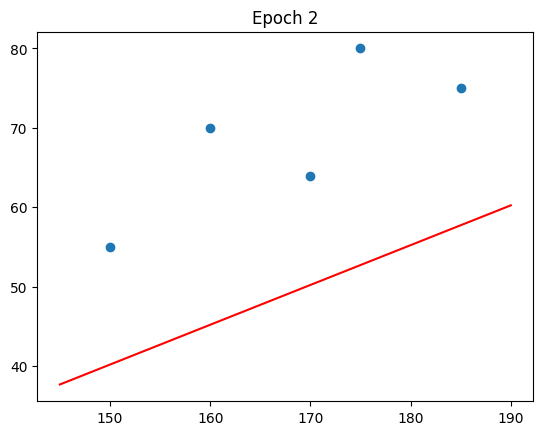

----------------------------------------
Epoch: 3, train loss: 495.9343
Weight: 0.5206, Bias: -34.9996


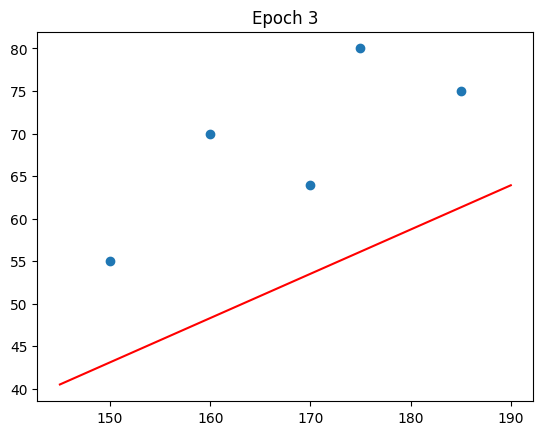

----------------------------------------
Epoch: 4, train loss: 382.3307
Weight: 0.5366, Bias: -34.9995


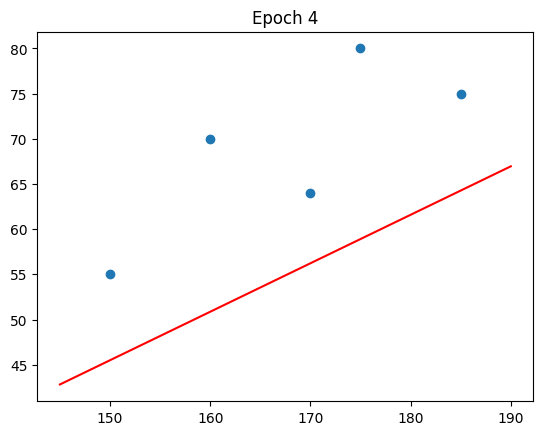

----------------------------------------
Epoch: 5, train loss: 304.1121
Weight: 0.5499, Bias: -34.9994


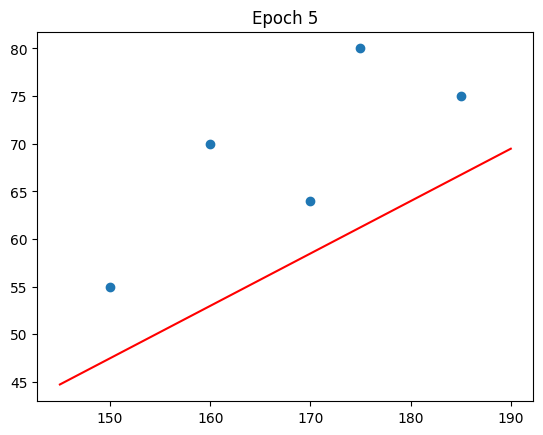

----------------------------------------
Epoch: 6, train loss: 250.2566
Weight: 0.5609, Bias: -34.9993


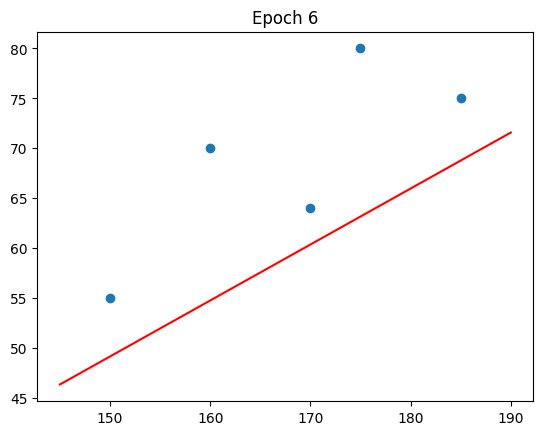

----------------------------------------
Epoch: 7, train loss: 213.1756
Weight: 0.5701, Bias: -34.9993


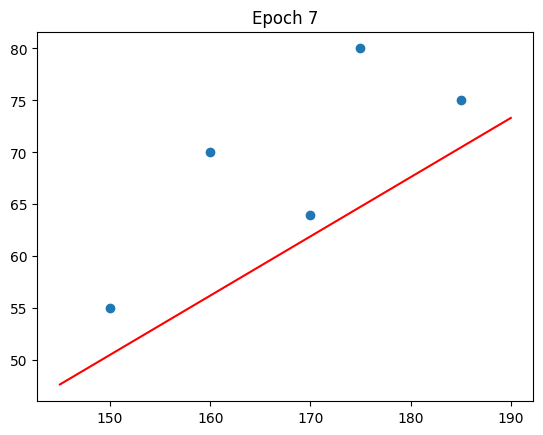

----------------------------------------
Epoch: 8, train loss: 187.6445
Weight: 0.5777, Bias: -34.9992


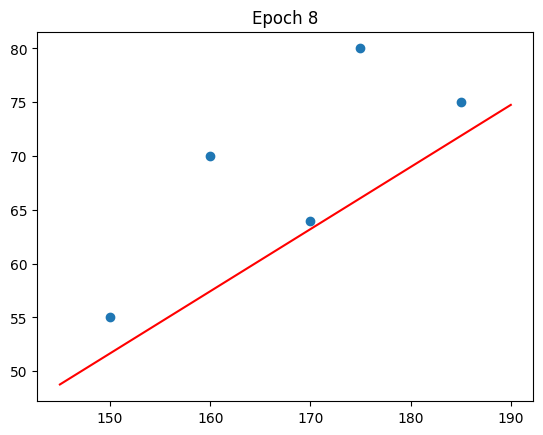

----------------------------------------
Epoch: 9, train loss: 170.0657
Weight: 0.5840, Bias: -34.9992


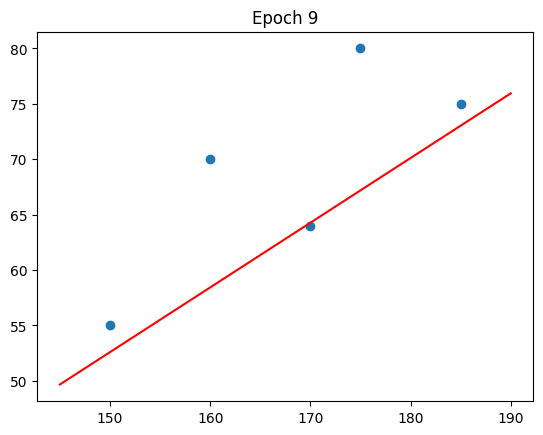

----------------------------------------
Epoch: 10, train loss: 157.9622
Weight: 0.5892, Bias: -34.9991


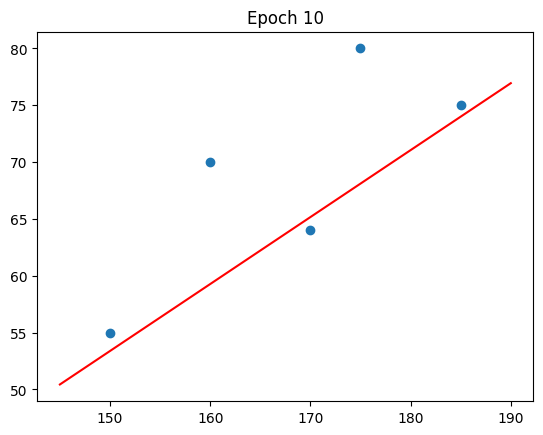

----------------------------------------
Epoch: 11, train loss: 149.6288
Weight: 0.5935, Bias: -34.9991


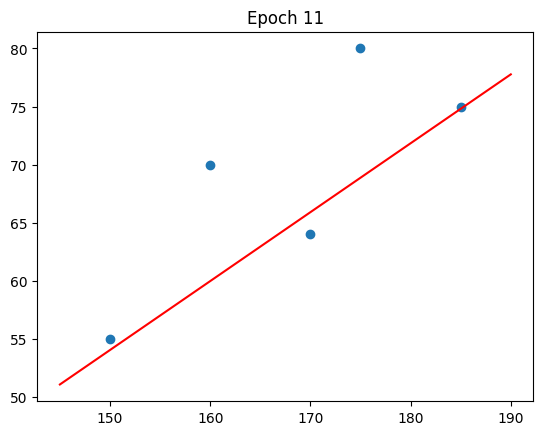

----------------------------------------
Epoch: 12, train loss: 143.8909
Weight: 0.5971, Bias: -34.9991


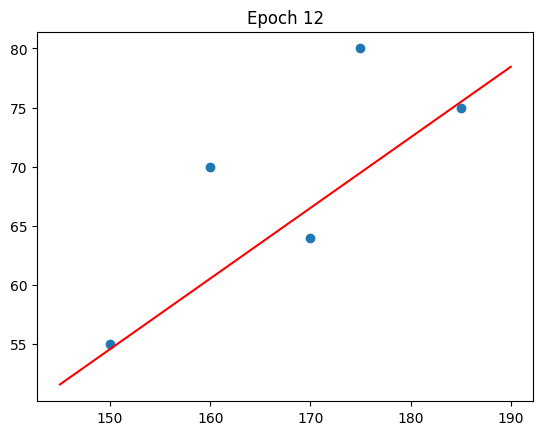

----------------------------------------
Epoch: 13, train loss: 139.9402
Weight: 0.6001, Bias: -34.9991


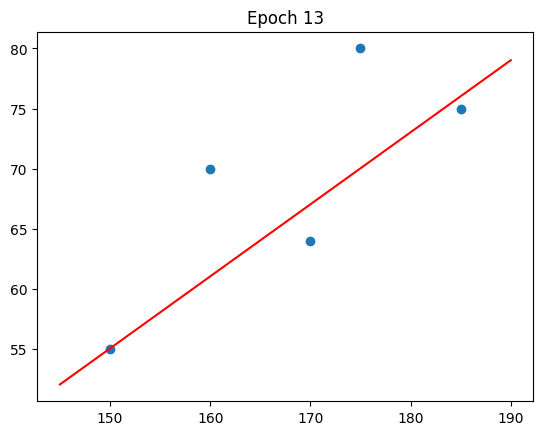

----------------------------------------
Epoch: 14, train loss: 137.2202
Weight: 0.6026, Bias: -34.9991


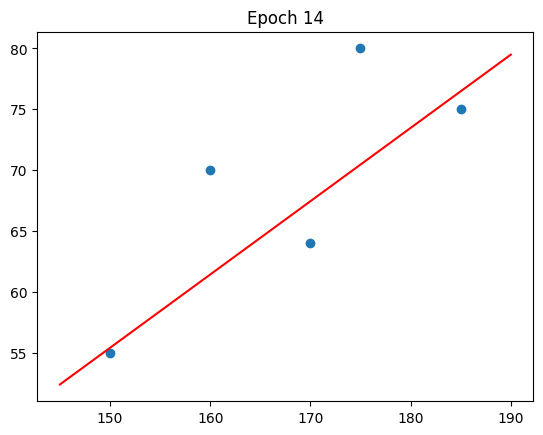

----------------------------------------
Epoch: 15, train loss: 135.3472
Weight: 0.6046, Bias: -34.9990


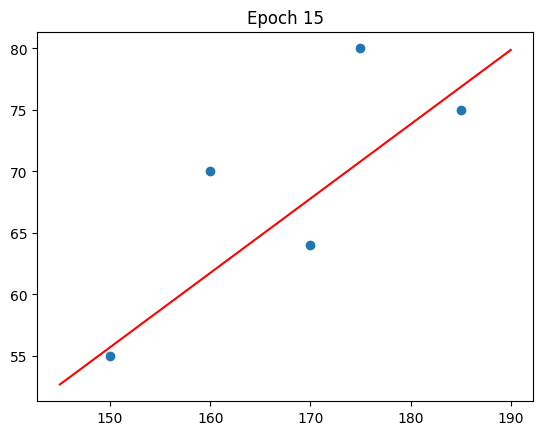

----------------------------------------
Epoch: 16, train loss: 134.0578
Weight: 0.6064, Bias: -34.9990


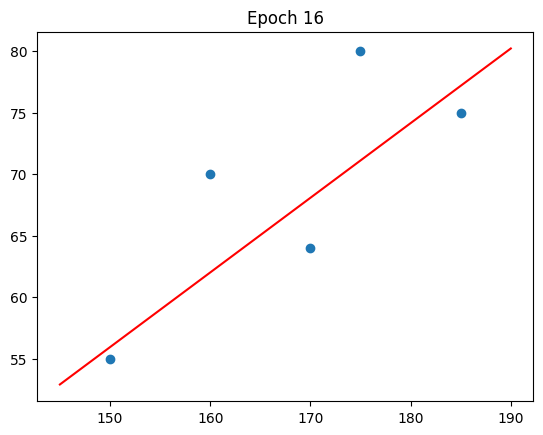

----------------------------------------
Epoch: 17, train loss: 133.1698
Weight: 0.6078, Bias: -34.9990


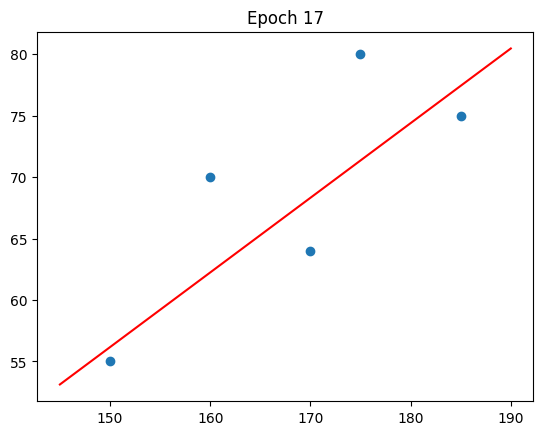

----------------------------------------
Epoch: 18, train loss: 132.5586
Weight: 0.6089, Bias: -34.9990


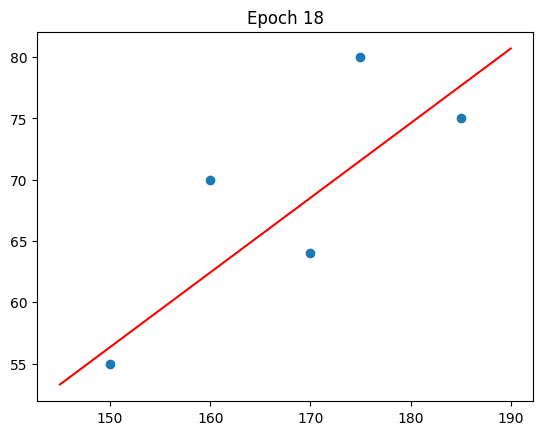

----------------------------------------
Epoch: 19, train loss: 132.1376
Weight: 0.6099, Bias: -34.9990


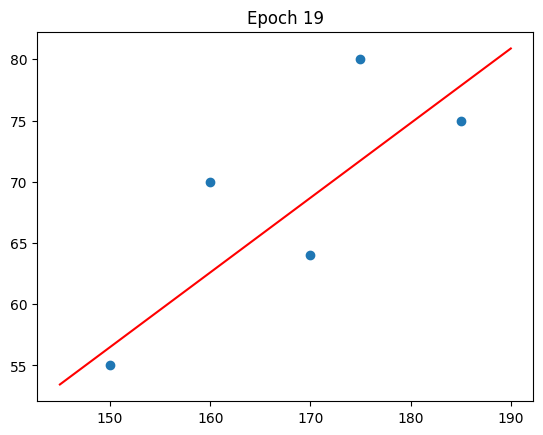

----------------------------------------
Epoch: 20, train loss: 131.8478
Weight: 0.6107, Bias: -34.9990


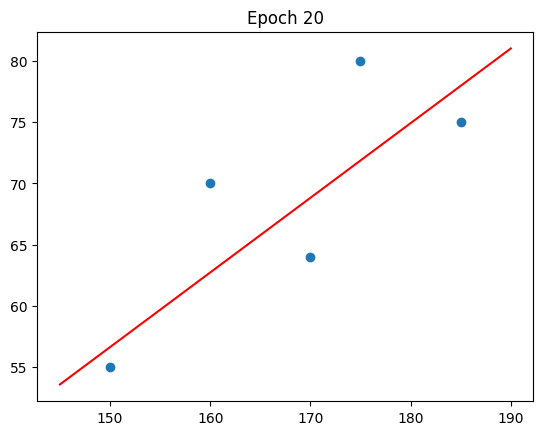

----------------------------------------


In [25]:
# 정석 코드
from torch import nn, optim

x = x.reshape(-1,1) # 개채 형태로 바꿔줌

model = nn.Linear(1,1)
model.weight.data = torch.tensor([[0.45]])
model.bias.data = torch.tensor([-35.])

LR = 3e-6
EPOCH = 20
optimizer = optim.SGD(model.parameters(), lr=LR)
criterion = nn.MSELoss()

loss_history = []

for ep in range(EPOCH):
    # inference
    y_hat = model(x)
    # loss
    loss = criterion(y_hat,y)
    # update
    optimizer.zero_grad() # gradient 초기화
    loss.backward() # backpropagation
    optimizer.step() # weight update
    # print loss
    loss_history += [loss.item()]
    print(f"Epoch: {ep+1}, train loss: {loss.item():.4f}")
    # print weight and bias
    print(f"Weight: {model.weight.data.item():.4f}, Bias: {model.bias.data.item():.4f}")
    # plot graph
    x_plot = torch.linspace(145,190,100)
    y_plot = model.weight.squeeze().detach() * x_plot + model.bias.data.detach()
    plt.figure()
    plt.plot(x,y,'o')
    plt.plot(x_plot,y_plot,'r')
    plt.title(f"Epoch {ep+1}")
    plt.show()

    print("-"*40)